# General Loan Data Pipeline

Start here for a new deal tape. The expected inputs are one origination-level dataset and one periodic performance dataset. The notebook keeps raw, standardized, merged, summary, and regression-ready DataFrames in memory so they can be opened in Data Wrangler.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from parentHelpers import *
from loanPipelineHelpers import *
from regression import *
from helperProjectDriver import *
from helperProjectAlamo import *

# Input Data Path

In [69]:
DATA_PATH = Path(r'\\file01\analysis\Consumer Opportunities\Porchpass\26Q2 Flow Opportunity\VDR\2 02 – Master Loan-Level Data\2.2 Data Room_Loan Tape_03312026.xlsx')
PERFORMANCE_DATA_PATH_OLD = Path(r"F:\Consumer Opportunities\Porchpass\26Q2 Flow Opportunity\VDR\2 02 – Master Loan-Level Data\2.5 Portfolio Paystring-2024-11-to-2026-04.xlsx")   

In [70]:
# DQ_DATA_PATH = Path(r"F:\Consumer Opportunities\Porchpass\26Q2 Flow Opportunity\VDR\2 02 – Master Loan-Level Data\Loan-Level DQ Ever Tracker_March EOM.xlsx")
DQ_DATA_PATH_NEW = Path(r"F:\Consumer Opportunities\Porchpass\26Q2 Flow Opportunity\VDR\PorchPass_Paystring_Tape_May2026_Bayview Request_06162026.xlsx")

In [71]:
perf_df_old[perf_df_old['porchpass_loan_id'] == 'loan_PdZHWW6oMxKH']

,porchpass_loan_id,partner_loan_id,period_end_date,period_label,origination_date,first_payment_due,loan_term_months,maturity_date,interest_rate,original_loan_balance,...,last_payment_interest,source_last_payment_principal,source_last_payment_interest,payoff_event_amount,next_payment_due,days_past_due,delinquency_flag,loan_status,payoff_indicator,charge_off_amount
2768,loan_PdZHWW6oMxKH,2024120903,2025-05-31,2025-05,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,0.00,0.00,0.00,NaN,2025-07-01,0,0.0,Performing,False,NaN
2769,loan_PdZHWW6oMxKH,2024120903,2025-06-30,2025-06,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,0.00,0.00,0.00,NaN,2025-07-01,0,0.0,Performing,False,NaN
2770,loan_PdZHWW6oMxKH,2024120903,2025-07-31,2025-07,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,0.00,0.00,0.00,NaN,2025-07-01,30,1.0,Collections,False,NaN
2771,loan_PdZHWW6oMxKH,2024120903,2025-08-31,2025-08,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,690.17,62.08,690.17,NaN,2025-08-01,31,1.0,Collections,False,NaN
2772,loan_PdZHWW6oMxKH,2024120903,2025-09-30,2025-09,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,689.65,62.60,689.65,NaN,2025-10-01,0,0.0,Performing,False,NaN
2773,loan_PdZHWW6oMxKH,2024120903,2025-10-31,2025-10,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,0.00,0.00,0.00,NaN,2025-10-01,30,1.0,Collections,False,NaN
2774,loan_PdZHWW6oMxKH,2024120903,2025-11-30,2025-11,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,0.00,0.00,0.00,NaN,2025-10-01,60,1.0,dq60+,False,NaN
2775,loan_PdZHWW6oMxKH,2024120903,2025-12-31,2025-12,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,0.00,0.00,0.00,NaN,2025-10-01,91,1.0,dq60+,False,NaN
2776,loan_PdZHWW6oMxKH,2024120903,2026-01-31,2026-01,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,689.13,63.12,689.13,NaN,2025-11-01,91,1.0,dq60+,False,NaN
2777,loan_PdZHWW6oMxKH,2024120903,2026-02-28,2026-02,2025-05-30,2025-07-01,300,2050-06-01,10.02,82655.08,...,1376.67,127.83,1376.67,NaN,2026-01-01,58,1.0,Collections,False,NaN


In [72]:
perf_df_old = read_in_files(PERFORMANCE_DATA_PATH_OLD)

Shape of the dataframe: (5820, 26)


,porchpass_loan_id,partner_loan_id,period_end_date,period_label,origination_date,first_payment_due,loan_term_months,maturity_date,interest_rate,original_loan_balance,...,last_payment_interest,source_last_payment_principal,source_last_payment_interest,payoff_event_amount,next_payment_due,days_past_due,delinquency_flag,loan_status,payoff_indicator,charge_off_amount
0,loan_ALPHAobz4xhf,2023113011,2024-12-31,2024-12,2024-12-27,2025-02-15,300,2050-01-15,8.38,159955.29,...,0.00,0.00,0.00,NaN,2025-02-15,0,0.0,Performing,False,NaN
1,loan_ALPHAobz4xhf,2023113011,2025-01-31,2025-01,2024-12-27,2025-02-15,300,2050-01-15,8.38,159955.29,...,0.00,0.00,0.00,NaN,2025-02-15,0,0.0,Performing,False,NaN
2,loan_ALPHAobz4xhf,2023113011,2025-02-28,2025-02,2024-12-27,2025-02-15,300,2050-01-15,8.38,159955.29,...,1117.02,158.07,1117.02,NaN,2025-03-15,0,0.0,Performing,False,NaN
3,loan_ALPHAobz4xhf,2023113011,2025-03-31,2025-03,2024-12-27,2025-02-15,300,2050-01-15,8.38,159955.29,...,1115.92,159.17,1115.92,NaN,2025-04-15,0,0.0,Performing,False,NaN
4,loan_ALPHAobz4xhf,2023113011,2025-04-30,2025-04,2024-12-27,2025-02-15,300,2050-01-15,8.38,159955.29,...,1114.81,160.28,1114.81,NaN,2025-05-15,0,0.0,Performing,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5815,new_300006180,300006180,2026-04-30,2026-04,2026-04-29,2026-05-15,240,2046-04-15,8.28,84583.44,...,0.00,0.00,0.00,NaN,2026-05-15,0,0.0,Performing,False,NaN
5816,new_300006200,300006200,2026-04-30,2026-04,2026-04-23,2026-05-15,240,2046-04-15,8.37,91172.46,...,0.00,0.00,0.00,NaN,2026-05-15,0,0.0,Performing,False,NaN
5817,new_300006207,300006207,2026-04-30,2026-04,2026-04-30,2026-06-01,240,2046-05-01,8.39,145604.48,...,0.00,0.00,0.00,NaN,2026-06-01,0,0.0,Performing,False,NaN
5818,new_300006225,300006225,2026-04-30,2026-04,2026-04-30,2026-06-01,240,2046-05-01,8.30,121726.83,...,0.00,0.00,0.00,NaN,2026-06-01,0,0.0,Performing,False,NaN


In [73]:
perf_df_raw = read_in_files(DQ_DATA_PATH_NEW, sheet_name="Paystring Tape v2")
perf_df_raw['midwest_loan'] = perf_df_raw['midwest_loan'].apply(lambda x: str(int(x)) if pd.notnull(x) else '')
perf_df_raw['madison_acct'] = perf_df_raw['madison_acct'].apply(lambda x: str(int(x)) if pd.notnull(x) else '')
# perf_df_raw['partner_loan_ids'] = perf_df_raw['partner_loan_ids'].apply(lambda x: str(int(x)) if pd.notnull(x) else '')

Shape of the dataframe: (5642, 28)


,porchpass_id,midwest_loan,madison_acct,old_porchpass_ids,partner_loan_ids,purchase_bundle,borrower_state,period_year,period_month,period_label,...,interest_rate,monthly_pi_payment,dealer_name,bank_purchaser_name,paystring_status_code,remit_loan_status,days_delinquent,last_payment_date,next_payment_due,times_dq30_plus_past_24_months
0,loan_n3EXWUJ9wZiE,5.001136e+09,2011083,20240902.9,202409029,Bundle 3,TX,2024.0,12.0,2024-12,...,9.51,976.89,Oak Creek Home Center,Rogue Credit Union,C,Performing,0,2024-12-17,NaT,0
1,loan_n3EXWUJ9wZiE,5.001136e+09,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,1.0,2025-01,...,9.51,976.89,Oak Creek Home Center,Rogue Credit Union,C,Performing,0,2025-01-21,NaT,0
2,loan_n3EXWUJ9wZiE,5.001136e+09,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,2.0,2025-02,...,9.51,976.89,Oak Creek Home Center,Rogue Credit Union,C,Performing,13,2025-01-21,NaT,0
3,loan_n3EXWUJ9wZiE,5.001136e+09,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,3.0,2025-03,...,9.51,976.89,Oak Creek Home Center,Rogue Credit Union,C,Performing,16,2025-03-18,NaT,0
4,loan_n3EXWUJ9wZiE,5.001136e+09,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,4.0,2025-04,...,9.51,976.89,Oak Creek Home Center,Rogue Credit Union,C,Performing,15,2025-04-15,2025-04-15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5637,NaN,5.001323e+09,5001323384,NaN,300006568,NaN,NaN,2026.0,5.0,2026-05,...,NaN,NaN,NaN,Rogue Credit Union,C,Performing,0,NaT,2026-06-15,0
5638,NaN,5.001323e+09,5001323392,NaN,300006504,NaN,NaN,2026.0,5.0,2026-05,...,NaN,NaN,NaN,Rogue Credit Union,C,Performing,0,NaT,2026-07-01,0
5639,NaN,5.001323e+09,5001323400,NaN,300005681,NaN,NaN,2026.0,5.0,2026-05,...,NaN,NaN,NaN,Rogue Credit Union,C,Performing,0,NaT,2026-06-15,0
5640,NaN,5.001323e+09,5001323418,NaN,300006130,NaN,NaN,2026.0,5.0,2026-05,...,NaN,NaN,NaN,Rogue Credit Union,C,Performing,0,NaT,2026-07-01,0


In [74]:
origination_raw = read_in_files(DATA_PATH)
origination_raw['mls_servicer_loan_id'] = origination_raw['mls_servicer_loan_id'].astype(str)
origination_raw['alt_loan_id'] = origination_raw['alt_loan_id'].astype(str)
origination_raw['origination_date'] = pd.to_datetime(origination_raw['origination_date'])
origination_raw['first_payment_due'] = pd.to_datetime(origination_raw['first_payment_due'])

Shape of the dataframe: (434, 66)


,report_as_of_date,mls_servicer_loan_id,alt_loan_id,fico_score,dti_ratio,credit_tier,borrower_income_frequency,borrower_income,borrower_id_type,borrower_city,...,expected_number_of_payments,expected_principal_paid,expected_interest_paid,actual_number_of_payments,actual_principal_collected,actual_interest_collected,actual_late_fees_collected,actual_number_of_late_payments,actual_days_payments_late_past_grace_period,interest_accrued_30_360
0,2026-03-31,5001135556,2011086,694,0.4400,1,Monthly,3940.87,Driver License,Atascosa,...,16,1849.841580,11030.979916,16,2012.79,11028.01,0,0,0,363.717939
1,2026-03-31,5001135564,2011087,600,0.4000,3,Bi-Weekly,2670.93,Driver License,Atascosa,...,16,1240.181354,15346.032088,16,1238.99,15348.30,80,4,0,953.285026
2,2026-03-31,5001135580,2011091,655,0.3000,2,Monthly,3523.33,Passport,Laredo,...,15,1423.645515,12338.554165,5,484.02,4131.12,80,4,319,0.000000
3,2026-03-31,5001135531,2011083,713,0.2100,2,Monthly,34318.25,Driver License,New Caney,...,16,1554.995113,14083.505341,17,1717.03,14954.52,200,10,0,0.000000
4,2026-03-31,5001135572,2011089,654,0.3400,2,Monthly,3809.87,Driver License,Alamo,...,17,1925.197668,16494.407584,16,1992.31,14559.25,180,9,1,1469.347888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,2026-03-31,5001144509,5001144509,725,0.3809,1,Monthly,4821.01,Drivers License,Rising Star,...,0,NaN,NaN,0,0.00,0.00,0,0,0,0.000000
430,2026-03-31,5001144491,5001144491,711,0.2818,1,Bi-Weekly,1892.80,Drivers License,Schulenburg,...,0,NaN,NaN,0,0.00,0.00,0,0,0,0.000000
431,2026-03-31,5001144483,5001144483,697,0.2379,1,Weekly,2070.40,Drivers License,Edna,...,0,NaN,NaN,0,0.00,0.00,0,0,0,0.000000
432,2026-03-31,300005608,300005608,714,0.2975,1,Bi-Weekly,3159.19,Drivers License,Needville,...,0,NaN,NaN,0,0.00,0.00,0,0,0,0.000000


In [75]:
origination_date_col = 'origination_date'
origination_raw = create_vintage(origination_raw, origination_date_col) # 

origination_raw = clean_alamo_categories(origination_raw)

In [76]:
ratio_cols = {
    "origination_fee": "origination fee %",
    "other_fees_in_loan_amt": "other_fees_in_loan_amt %",
}

origination_raw, non_numeric_fee_rows = add_ratio_columns(
    origination_raw,
    numerator_cols=ratio_cols,
    denominator_col="original_loan_balance",
    return_invalid_rows=True,
)

print(f"Rows with non-numeric fee/balance values coerced to NaN: {len(non_numeric_fee_rows)}")
display(non_numeric_fee_rows.head(20))

Rows with non-numeric fee/balance values coerced to NaN: 19


,origination_fee,other_fees_in_loan_amt,original_loan_balance
120,x,x,141531.09
129,x,x,88702.30
417,NaN,NaN,116635.90
418,NaN,NaN,128569.10
419,NaN,NaN,111496.95
420,NaN,NaN,148946.05
421,NaN,NaN,108288.94
422,NaN,NaN,87783.74
423,NaN,NaN,96288.33
424,NaN,NaN,70731.46


In [77]:
origination_raw = add_fico_bucket_column(
    origination_raw,
    fico_col="fico_score",
    bucket_col="fico_bucket",
)

origination_raw['borrower_annual_income'] = origination_raw.apply(lambda x: clean_borrower_income(x), axis=1)

In [78]:
perf_df_raw['period_end_date'] = pd.to_datetime(perf_df_raw['period_end_date'])
perf_df_old['period_end_date'] = pd.to_datetime(perf_df_old['period_end_date'])

perf_df_raw = perf_df_raw.merge(perf_df_old[['porchpass_loan_id', 'period_end_date', 'beginning_balance', 
                                   'unpaid_principal_balance', 
                                   'expected_monthly_payment',
                                   'days_past_due',
                                    'actual_payment_pi', 'last_payment_principal', 'last_payment_interest',
                                    'source_last_payment_principal', 'source_last_payment_interest',
                                    'payoff_indicator', 'payoff_event_amount', 'next_payment_due']], 
                      right_on = ['porchpass_loan_id', 'period_end_date'], 
                      left_on = ['porchpass_id', 'period_end_date'], how = 'left')

In [79]:
origination_to_append = origination_raw[
    ['report_as_of_date', 
     'mls_servicer_loan_id', 
     'alt_loan_id', 
     'fico_score', 
     'dti_ratio', 
     'credit_tier', 
     'borrower_income_frequency', 
     'borrower_income', 
     'borrower_id_type', 
     'borrower_city', 
     'borrower_state', 
     'borrower_zip_code', 
     'msa', 
     'land_type', 
     'property_value', 
     'property_valuation_date', 
     'data_comp_value', 
     'addon_value', 
     'ltv_ratio_origination', 
     'current_ltv', 
     'original_loan_balance', 
     'current_upb', 
     'interest_rate', 
     'loan_term_months', 
     'monthly_p&i_payment', 
     'monthly_escrow_payment', 
     'maturity_date', 
     'closing_date', 
     'origination_date', 
     'first_payment_due', 
     'days_btwn_funding_and_first_pmt_due', 
     'dealer_name', 
     'bank_purchaser_name', 
     'date_sale_approved_by_investor', 
     'money_deployed', 
     'origination_fee', 
     'other_fees_in_loan_amt', 
     #'last_payment_date', 
     #'last_payment_due', 
     #'next_payment_due', 
     'interest_paid_to_date', 
    # 'last_payment_principal', 'last_payment_interest', 'expected_next_interest_payment', 'paid_ahead_flag', 'days_past_due', 
     #'delinquency_bucket', 
     #'loan_status', 
     'times_dq30+_in_past_24_months', 
    #  'months_since_last_delinquency', 'months_to_first_delinquency', 'Seasoning (MOB)', 'Remaining Term (Months)', 
    # 'Loan Age Bucket', 
    'Cumulative Principal Paydown Rate (%)', 'Payment-to-Income Ratio', 
    'expected_number_of_payments', 'expected_principal_paid', 
    'expected_interest_paid', 'actual_number_of_payments', 
    'actual_principal_collected', 'actual_interest_collected', 
    'actual_late_fees_collected', 'actual_number_of_late_payments', 
    'actual_days_payments_late_past_grace_period', 
    'interest_accrued_30_360', 'Origination Month', 
    'Origination Quarter', 'land_type_clean', 'borrower_id_type_clean', 'borrower_income_frequency_clean', 
    'origination fee %', 'other_fees_in_loan_amt %', 'fico_bucket', 'borrower_annual_income']]

# Merge two dataframes with multiple keys, prioritizing primary keys and then secondary keys for unmatched rows.

# First merge on primary keys (mls_servicer_loan_id, midwest_loan)
merged_primary = perf_df_raw.merge(
    origination_to_append,
    left_on='midwest_loan',
    right_on='mls_servicer_loan_id',
    how='inner',
    suffixes=('', '_orig')
)

# Find rows from df1 that didn't match
unmatched_df1 = perf_df_raw[~perf_df_raw['midwest_loan'].isin(merged_primary['midwest_loan'])]

# Merge unmatched rows on secondary keys (alt_loan_id, madison_acct)
merged_secondary = unmatched_df1.merge(
    origination_to_append,
    left_on='madison_acct',
    right_on='alt_loan_id',
    how='inner',
    suffixes=('', '_orig')
)

result = pd.concat([merged_primary, merged_secondary], ignore_index=True)

unmatched_df2 = perf_df_raw[~perf_df_raw['midwest_loan'].isin(merged_primary['midwest_loan']) & ~perf_df_raw['madison_acct'].isin(merged_secondary['madison_acct'])]

# merged_tertiary = unmatched_df2.merge(
#     origination_raw,
#     left_on=['original_loan_balance', 'interest_rate', 'loan_term_months'],
#     right_on=['original_loan_balance', 'interest_rate', 'loan_term_months'],
#     how='inner'
# )

# # Combine all merges
# result = pd.concat([merged_primary, merged_secondary, merged_tertiary], ignore_index=True)

In [80]:
result['new_loan_id'] = result.apply(lambda row: row['midwest_loan'] 
                                     if pd.notnull(row['midwest_loan']) 
                                     else row['madison_acct'], axis=1)
origination_raw['new_loan_id'] = origination_raw.apply(lambda row: 
                                                       row['mls_servicer_loan_id'] 
                                                       if pd.notnull(row['mls_servicer_loan_id']) 
                                                       else row['alt_loan_id'], axis=1)

In [86]:
result[(result['days_delinquent'] != result['days_past_due']) & 
       (result['period_end_date'] <= '2026-03-01') &
       (result['period_end_date'] >= '2026-01-01')][['porchpass_id', 
                                                              'period_end_date', 
                                                              'days_delinquent', 'days_past_due', 
                                                              'beginning_balance', 
                                   'unpaid_principal_balance', 
                                   'expected_monthly_payment',
                                   
                                    'actual_payment_pi', 'last_payment_principal', 'last_payment_interest',
                                    'source_last_payment_principal', 'source_last_payment_interest',
                                    'payoff_indicator', 'payoff_event_amount']] 

,porchpass_id,period_end_date,days_delinquent,days_past_due,beginning_balance,unpaid_principal_balance,expected_monthly_payment,actual_payment_pi,last_payment_principal,last_payment_interest,source_last_payment_principal,source_last_payment_interest,payoff_indicator,payoff_event_amount
49,loan_7Zd1PcX4JvXr,2026-01-31,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,loan_7Zd1PcX4JvXr,2026-02-28,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
421,loan_ji7y6H1zNGMW,2026-01-31,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
422,loan_ji7y6H1zNGMW,2026-02-28,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1113,loan_YZRyPpYGaRYF,2026-01-31,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1114,loan_YZRyPpYGaRYF,2026-02-28,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1294,loan_fLRxY8UgC2d8,2026-01-31,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1295,loan_fLRxY8UgC2d8,2026-02-28,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1416,loan_DWqX8B7o29dk,2026-01-31,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1417,loan_DWqX8B7o29dk,2026-02-28,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
result[result['porchpass_id'] == 'loan_RLLJ66cAP2Hy'][['porchpass_id', 
                                                              'period_end_date', 
                                                              'beginning_balance', 
                                                              'days_delinquent', 
                                                            #   'days_past_due', 
                                                              
                                #    'unpaid_principal_balance', 
                                   'expected_monthly_payment',
                                   
                                    'actual_payment_pi', 
                                    'last_payment_principal', 'last_payment_interest']]
                                    # 'source_last_payment_principal', 'source_last_payment_interest',
                                    # 'payoff_indicator', 'payoff_event_amount']] 

,porchpass_id,period_end_date,beginning_balance,days_delinquent,expected_monthly_payment,actual_payment_pi,last_payment_principal,last_payment_interest
2744,loan_RLLJ66cAP2Hy,2025-04-30,83170.91,15,679.27,0.00,0.00,0.00
2745,loan_RLLJ66cAP2Hy,2025-05-31,83170.91,16,679.27,679.27,78.36,600.91
2746,loan_RLLJ66cAP2Hy,2025-06-30,83092.55,0,679.27,1358.54,158.43,1200.11
2747,loan_RLLJ66cAP2Hy,2025-07-31,82934.12,16,679.27,0.00,0.00,0.00
2748,loan_RLLJ66cAP2Hy,2025-08-31,82934.13,16,679.27,679.27,80.07,599.20
2749,loan_RLLJ66cAP2Hy,2025-09-30,82854.06,15,679.27,679.27,80.65,598.62
2750,loan_RLLJ66cAP2Hy,2025-10-31,82773.41,46,679.27,0.00,0.00,0.00
2751,loan_RLLJ66cAP2Hy,2025-11-30,82773.41,46,679.27,679.27,81.23,598.04
2752,loan_RLLJ66cAP2Hy,2025-12-31,82692.18,77,679.27,0.00,0.00,0.00
2753,loan_RLLJ66cAP2Hy,2026-01-31,82692.18,108,679.27,0.00,0.00,0.00


In [84]:
perf_df_old[perf_df_old['porchpass_loan_id'] == 'loan_n3EXWUJ9wZiE']

,porchpass_loan_id,partner_loan_id,period_end_date,period_label,origination_date,first_payment_due,loan_term_months,maturity_date,interest_rate,original_loan_balance,...,last_payment_interest,source_last_payment_principal,source_last_payment_interest,payoff_event_amount,next_payment_due,days_past_due,delinquency_flag,loan_status,payoff_indicator,charge_off_amount
341,loan_n3EXWUJ9wZiE,202409029,2025-03-31,2025-03,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,884.42,92.47,884.42,NaN,2025-04-15,0,0.0,Performing,False,NaN
342,loan_n3EXWUJ9wZiE,202409029,2025-04-30,2025-04,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,883.69,93.20,883.69,NaN,2025-05-15,0,0.0,Performing,False,NaN
343,loan_n3EXWUJ9wZiE,202409029,2025-05-31,2025-05,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,882.95,93.94,882.95,NaN,2025-06-15,0,0.0,Performing,False,NaN
344,loan_n3EXWUJ9wZiE,202409029,2025-06-30,2025-06,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,882.20,94.69,882.20,NaN,2025-07-15,0,0.0,Performing,False,NaN
345,loan_n3EXWUJ9wZiE,202409029,2025-07-31,2025-07,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,881.45,95.44,881.45,NaN,2025-08-15,0,0.0,Performing,False,NaN
346,loan_n3EXWUJ9wZiE,202409029,2025-08-31,2025-08,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,880.20,96.69,880.20,NaN,2025-08-15,16,1.0,Performing,False,NaN
347,loan_n3EXWUJ9wZiE,202409029,2025-09-30,2025-09,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,879.43,97.46,879.43,NaN,2025-09-15,15,1.0,Performing,False,NaN
348,loan_n3EXWUJ9wZiE,202409029,2025-10-31,2025-10,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,878.66,98.23,878.66,NaN,2025-10-15,16,1.0,Performing,False,NaN
349,loan_n3EXWUJ9wZiE,202409029,2025-11-30,2025-11,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,877.88,99.01,877.88,NaN,2025-11-15,15,1.0,Performing,False,NaN
350,loan_n3EXWUJ9wZiE,202409029,2025-12-31,2025-12,2024-11-07,2024-12-15,300,2049-11-15,9.51,111781.26,...,0.00,0.00,0.00,NaN,2025-11-15,46,1.0,Collections,False,NaN


In [59]:
perf_df = result.copy()  

In [60]:
# import pandas as pd

df = result.copy()  

id_col = "new_loan_id"
period_col = "period_end_date"
first_due_col = "first_payment_due"
payoff_col = "payoff_indicator"
orig_bal_col = "original_loan_balance"

df[id_col] = df[id_col].astype(str)
df[period_col] = pd.to_datetime(df[period_col]).dt.to_period("M").dt.to_timestamp("M")
df[first_due_col] = pd.to_datetime(df[first_due_col])

file_cutoff = pd.Timestamp("2026-04-30")

duplicate_loan_months = (
    df[df.duplicated([id_col, period_col], keep=False)]
    .sort_values([id_col, period_col])
)

missing_rows = []
summary_rows = []

for loan_id, g in df.groupby(id_col, dropna=False):
    first_due = g[first_due_col].dropna().min()
    orig_bal = pd.to_numeric(g[orig_bal_col], errors="coerce").dropna()
    original_loan_amount = orig_bal.iloc[0] if len(orig_bal) else pd.NA
    if pd.isna(first_due):
        continue

    first_due_month_end = first_due.to_period("M").to_timestamp("M")
    actual_periods = set(g[period_col].dropna())
    actual_sorted = sorted(actual_periods)

    if not actual_sorted or first_due_month_end > file_cutoff:
        continue

    first_actual_period = actual_sorted[0]
    last_actual_period = actual_sorted[-1]

    expected_within_observed = pd.date_range(
        first_due_month_end,
        last_actual_period,
        freq="M",
    )

    expected_to_file_cutoff = pd.date_range(
        first_due_month_end,
        file_cutoff,
        freq="M",
    )

    missing_within_observed = [
        d for d in expected_within_observed if d not in actual_periods
    ]

    missing_to_file_cutoff = [
        d for d in expected_to_file_cutoff if d not in actual_periods
    ]

    for d in missing_to_file_cutoff:
        missing_rows.append({
            id_col: loan_id,
            "original_loan_amount": original_loan_amount,
            "first_payment_due": first_due,
            "missing_period_end_date": d,
            "first_actual_period": first_actual_period,
            "last_actual_period": last_actual_period,
            "missing_within_observed_life": d in missing_within_observed,
        })

    summary_rows.append({
        id_col: loan_id,
        "original_loan_amount": original_loan_amount,
        "first_payment_due": first_due,
        "first_due_month_end": first_due_month_end,
        "first_actual_period": first_actual_period,
        "last_actual_period": last_actual_period,
        "actual_record_count": len(actual_periods),
        "missing_within_observed_life_count": len(missing_within_observed),
        "missing_to_file_cutoff_count": len(missing_to_file_cutoff),
        "missing_within_observed_life_months": ", ".join(d.strftime("%Y-%m") for d in missing_within_observed),
        "missing_to_file_cutoff_months": ", ".join(d.strftime("%Y-%m") for d in missing_to_file_cutoff),
    })

missing_payment_rows = pd.DataFrame(missing_rows)
payment_record_summary = pd.DataFrame(summary_rows)

print("File cutoff:", file_cutoff.date())
print("Duplicate loan-month rows:", len(duplicate_loan_months))
print("Loans missing rows within observed life:",
      (payment_record_summary["missing_within_observed_life_count"] > 0).sum())
print("Missing rows within observed life:",
      payment_record_summary["missing_within_observed_life_count"].sum())
print("Loans missing rows through file cutoff:",
      (payment_record_summary["missing_to_file_cutoff_count"] > 0).sum())
print("Missing rows through file cutoff:",
      payment_record_summary["missing_to_file_cutoff_count"].sum())

display(
    payment_record_summary
    .query("missing_to_file_cutoff_count > 0")
    .sort_values("missing_to_file_cutoff_count", ascending=False)
)

display(missing_payment_rows.sort_values([id_col, "missing_period_end_date"]))



missing_payment_df = payment_record_summary.query("missing_to_file_cutoff_count > 0").sort_values("missing_to_file_cutoff_count", ascending=False)
# missing_payment_df.to_excel("payment_record_missing_summary.xlsx", index=False)

display(missing_payment_df)


C:\Users\YuemengZhang\AppData\Local\Temp\ipykernel_65472\117101331.py:42: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  expected_within_observed = pd.date_range(
C:\Users\YuemengZhang\AppData\Local\Temp\ipykernel_65472\117101331.py:48: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  expected_to_file_cutoff = pd.date_range(


File cutoff: 2026-04-30
Duplicate loan-month rows: 41
Loans missing rows within observed life: 12
Missing rows within observed life: 22
Loans missing rows through file cutoff: 15
Missing rows through file cutoff: 33


,new_loan_id,original_loan_amount,first_payment_due,first_due_month_end,first_actual_period,last_actual_period,actual_record_count,missing_within_observed_life_count,missing_to_file_cutoff_count,missing_within_observed_life_months,missing_to_file_cutoff_months
0,,60681.46,2025-01-01,2025-01-31,2025-01-31,2025-11-30,11,0,5,,"2025-12, 2026-01, 2026-02, 2026-03, 2026-04"
93,5001136208,60213.04,2025-03-15,2025-03-31,2025-03-31,2026-01-31,9,2,5,"2025-04, 2025-05","2025-04, 2025-05, 2026-02, 2026-03, 2026-04"
2,5001135291,70081.36,2025-03-01,2025-03-31,2025-03-31,2026-05-31,13,2,2,"2025-04, 2025-05","2025-04, 2025-05"
29,5001135564,108233.00,2024-12-01,2024-12-31,2024-12-31,2026-05-31,16,2,2,"2025-04, 2025-05","2025-04, 2025-05"
35,5001135622,85605.89,2025-01-01,2025-01-31,2024-12-31,2026-05-31,16,2,2,"2025-04, 2025-05","2025-04, 2025-05"
40,5001135671,115231.42,2025-01-15,2025-01-31,2025-01-31,2026-05-31,15,2,2,"2025-04, 2025-05","2025-04, 2025-05"
48,5001135754,96646.82,2025-01-15,2025-01-31,2025-01-31,2026-05-31,15,2,2,"2025-04, 2025-05","2025-04, 2025-05"
49,5001135762,124328.19,2025-01-15,2025-01-31,2025-01-31,2026-05-31,15,2,2,"2025-04, 2025-05","2025-04, 2025-05"
52,5001135796,81889.36,2025-01-01,2025-01-31,2025-01-31,2026-05-31,15,2,2,"2025-04, 2025-05","2025-04, 2025-05"
55,5001135820,98262.71,2025-02-01,2025-02-28,2025-02-28,2026-05-31,14,2,2,"2025-04, 2025-05","2025-04, 2025-05"


,new_loan_id,original_loan_amount,first_payment_due,missing_period_end_date,first_actual_period,last_actual_period,missing_within_observed_life
0,,60681.46,2025-01-01,2025-12-31,2025-01-31,2025-11-30,False
1,,60681.46,2025-01-01,2026-01-31,2025-01-31,2025-11-30,False
2,,60681.46,2025-01-01,2026-02-28,2025-01-31,2025-11-30,False
3,,60681.46,2025-01-01,2026-03-31,2025-01-31,2025-11-30,False
4,,60681.46,2025-01-01,2026-04-30,2025-01-31,2025-11-30,False
5,5001135291,70081.36,2025-03-01,2025-04-30,2025-03-31,2026-05-31,True
6,5001135291,70081.36,2025-03-01,2025-05-31,2025-03-31,2026-05-31,True
7,5001135564,108233.00,2024-12-01,2025-04-30,2024-12-31,2026-05-31,True
8,5001135564,108233.00,2024-12-01,2025-05-31,2024-12-31,2026-05-31,True
9,5001135622,85605.89,2025-01-01,2025-04-30,2024-12-31,2026-05-31,True


,new_loan_id,original_loan_amount,first_payment_due,first_due_month_end,first_actual_period,last_actual_period,actual_record_count,missing_within_observed_life_count,missing_to_file_cutoff_count,missing_within_observed_life_months,missing_to_file_cutoff_months
0,,60681.46,2025-01-01,2025-01-31,2025-01-31,2025-11-30,11,0,5,,"2025-12, 2026-01, 2026-02, 2026-03, 2026-04"
93,5001136208,60213.04,2025-03-15,2025-03-31,2025-03-31,2026-01-31,9,2,5,"2025-04, 2025-05","2025-04, 2025-05, 2026-02, 2026-03, 2026-04"
2,5001135291,70081.36,2025-03-01,2025-03-31,2025-03-31,2026-05-31,13,2,2,"2025-04, 2025-05","2025-04, 2025-05"
29,5001135564,108233.00,2024-12-01,2024-12-31,2024-12-31,2026-05-31,16,2,2,"2025-04, 2025-05","2025-04, 2025-05"
35,5001135622,85605.89,2025-01-01,2025-01-31,2024-12-31,2026-05-31,16,2,2,"2025-04, 2025-05","2025-04, 2025-05"
40,5001135671,115231.42,2025-01-15,2025-01-31,2025-01-31,2026-05-31,15,2,2,"2025-04, 2025-05","2025-04, 2025-05"
48,5001135754,96646.82,2025-01-15,2025-01-31,2025-01-31,2026-05-31,15,2,2,"2025-04, 2025-05","2025-04, 2025-05"
49,5001135762,124328.19,2025-01-15,2025-01-31,2025-01-31,2026-05-31,15,2,2,"2025-04, 2025-05","2025-04, 2025-05"
52,5001135796,81889.36,2025-01-01,2025-01-31,2025-01-31,2026-05-31,15,2,2,"2025-04, 2025-05","2025-04, 2025-05"
55,5001135820,98262.71,2025-02-01,2025-02-28,2025-02-28,2026-05-31,14,2,2,"2025-04, 2025-05","2025-04, 2025-05"


In [18]:
print('Missing Payment Ratio: {:.2%}'.format(sum(missing_payment_df['original_loan_amount']) / sum(origination_raw['original_loan_balance'])))

df_all = result.copy()
# df_all = perf_df[(~perf_df['new_loan_id'].isin(list(missing_payment_df['new_loan_id']))) & (perf_df['new_loan_id'].notna()) & (perf_df['origination_date'] <= '2026-03-31')]
df_all['period_end_date'] = pd.to_datetime(df_all['period_end_date'])

df_all["period_end_date"] = pd.to_datetime(df_all["period_end_date"])
df_all["origination_date"] = pd.to_datetime(df_all["origination_date"])
df_all["first_payment_due"] = pd.to_datetime(df_all["first_payment_due"])

df_all["mob"] = (
    (df_all["period_end_date"].dt.year - df_all["origination_date"].dt.year) * 12
    + (df_all["period_end_date"].dt.month - df_all["origination_date"].dt.month)
)

df_all["loan age since first payment"] = (
    (df_all["period_end_date"].dt.year - df_all["first_payment_due"].dt.year) * 12
    + (df_all["period_end_date"].dt.month - df_all["first_payment_due"].dt.month)
)

Missing Payment Ratio: 2.73%


In [19]:
origination_mod = df_all[df_all['mob'] == 1]
len(origination_mod)

293

In [20]:
df_all.head()

,porchpass_id,midwest_loan,madison_acct,old_porchpass_ids,partner_loan_ids,purchase_bundle,borrower_state,period_year,period_month,period_label,...,origination fee %,other_fees_in_loan_amt %,fico_bucket,borrower_annual_income,new_loan_id,porchpass_loan_id,beginning_balance,unpaid_principal_balance,mob,loan age since first payment
0,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2024.0,12.0,2024-12,...,0.045346,0.00492,700-739,411819.0,5001135531,NaN,NaN,NaN,1.0,0.0
1,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,1.0,2025-01,...,0.045346,0.00492,700-739,411819.0,5001135531,NaN,NaN,NaN,2.0,1.0
2,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,2.0,2025-02,...,0.045346,0.00492,700-739,411819.0,5001135531,NaN,NaN,NaN,3.0,2.0
3,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,3.0,2025-03,...,0.045346,0.00492,700-739,411819.0,5001135531,loan_n3EXWUJ9wZiE,111598.50,111506.03,4.0,3.0
4,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,4.0,2025-04,...,0.045346,0.00492,700-739,411819.0,5001135531,loan_n3EXWUJ9wZiE,111506.03,111412.83,5.0,4.0


### Origination Trends

In [21]:
groupby_col = "Origination Month"
weighted_col = "original_loan_balance"

cols_to_analyze_categorical = filter_existing_columns(
    # origination_mod,
    origination_mod,
    [
        "credit_tier",
        "fico_bucket",
        # "borrower_income_frequency_clean",
        # "borrower_id_type_clean",
        "loan_term_months",
        "land_type_clean",
        # "fico_bucket"
    ],
)

cols_to_analyze_numeric = filter_existing_columns(
    # origination_raw,
    origination_mod,
    [
        "fico_score",
        "dti_ratio",
        "credit_tier",
        # "borrower_income",
        'borrower_annual_income',
        "ltv_ratio_origination",
        "current_ltv",
        "original_loan_balance",
        "interest_rate",
        "loan_term_months",
        "monthly_p&i_payment",
        "payment_"
        "origination fee %",
        "other_fees_in_loan_amt %",
        "Payment-to-Income Ratio"
    ],
)

print("Categorical columns:", cols_to_analyze_categorical)
print("Numeric columns:", cols_to_analyze_numeric)

Categorical columns: ['credit_tier', 'fico_bucket', 'loan_term_months', 'land_type_clean']
Numeric columns: ['fico_score', 'dti_ratio', 'credit_tier', 'borrower_annual_income', 'ltv_ratio_origination', 'current_ltv', 'original_loan_balance', 'interest_rate', 'loan_term_months', 'monthly_p&i_payment', 'other_fees_in_loan_amt %', 'Payment-to-Income Ratio']


g:\YuemengZhang\Deal Opportunities - Clean\parentHelpers.py:451: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wt_distribution = wt_distribution.applymap(lambda x: f"{x:.2%}")


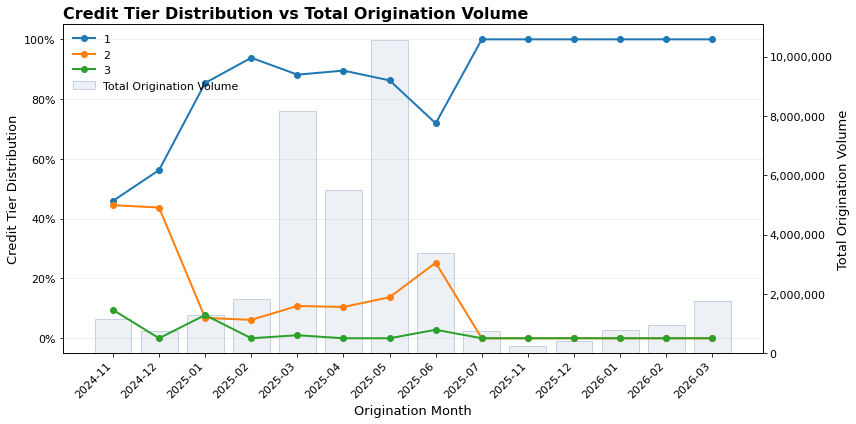

g:\YuemengZhang\Deal Opportunities - Clean\parentHelpers.py:445: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wt_distribution_ = df.groupby([col, vintage])[[weight_by]].sum().unstack(fill_value=0)
g:\YuemengZhang\Deal Opportunities - Clean\parentHelpers.py:451: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wt_distribution = wt_distribution.applymap(lambda x: f"{x:.2%}")


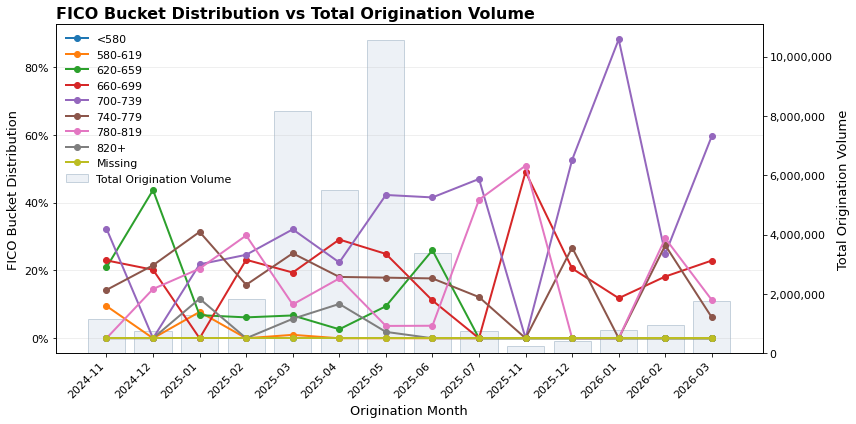

g:\YuemengZhang\Deal Opportunities - Clean\parentHelpers.py:451: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wt_distribution = wt_distribution.applymap(lambda x: f"{x:.2%}")


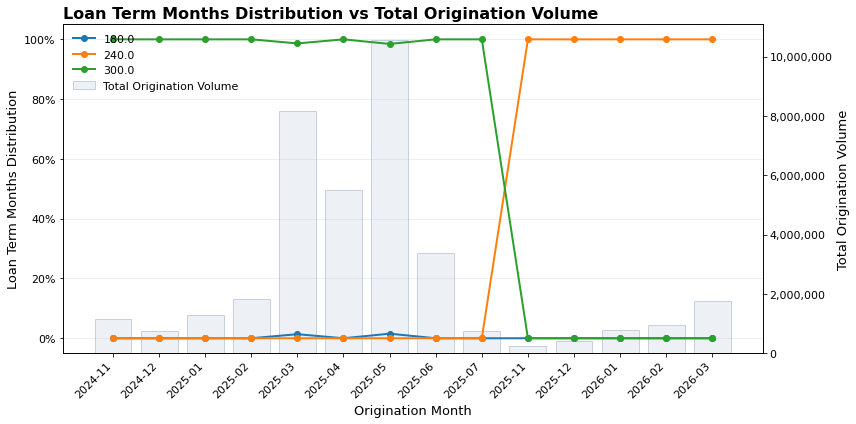

g:\YuemengZhang\Deal Opportunities - Clean\parentHelpers.py:451: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wt_distribution = wt_distribution.applymap(lambda x: f"{x:.2%}")


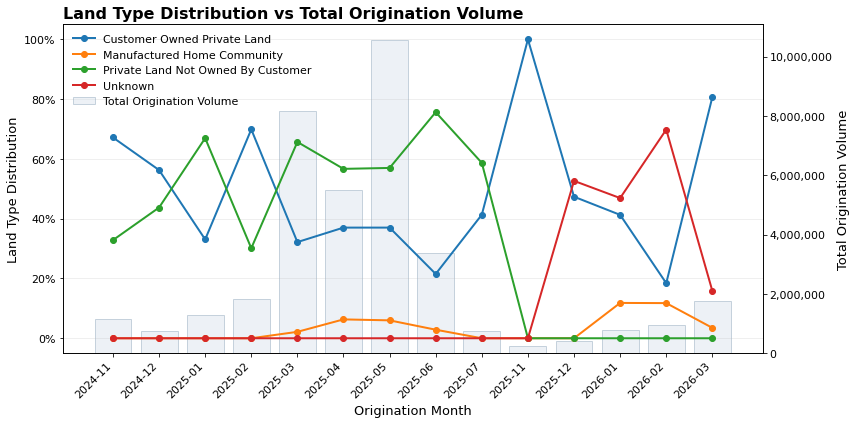

In [22]:
results = plot_distribution_for_categorical(
    # origination_raw,
    origination_mod,
    cols_to_analyze_categorical,
    groupby_col,
    weighted_col,
    total_volume_row="Total Origination",
    x_label=None,
    volume_ylabel="Total Origination Volume",
    category_label_format="{category}",
    figsize=(12, 6),
    sort_by_col=None,
    format_pct=True,
    show=True
)

g:\YuemengZhang\Deal Opportunities - Clean\parentHelpers.py:618: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(groupby_col)


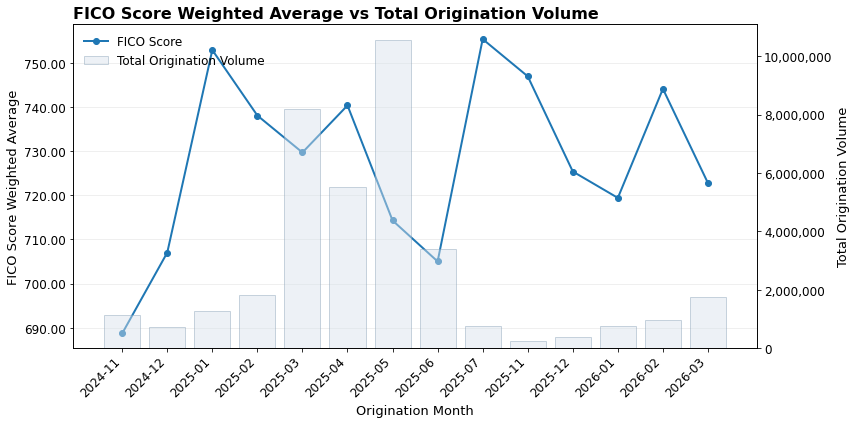

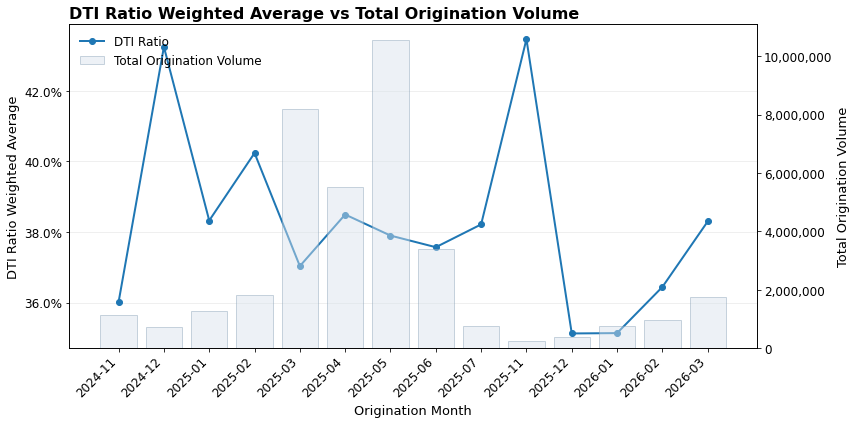

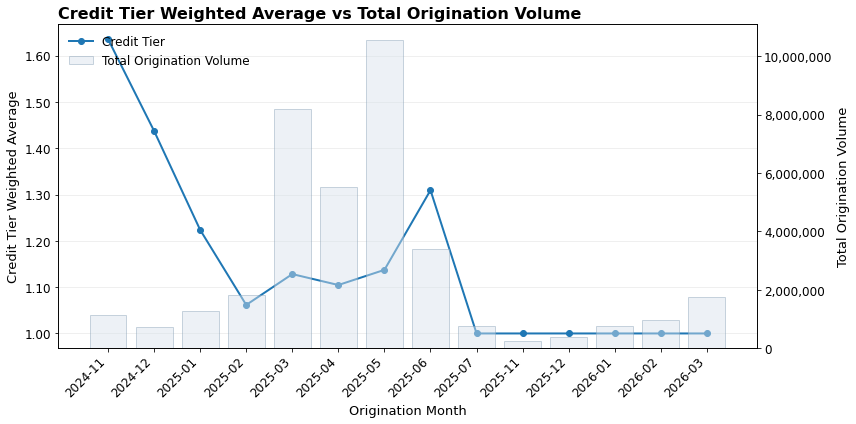

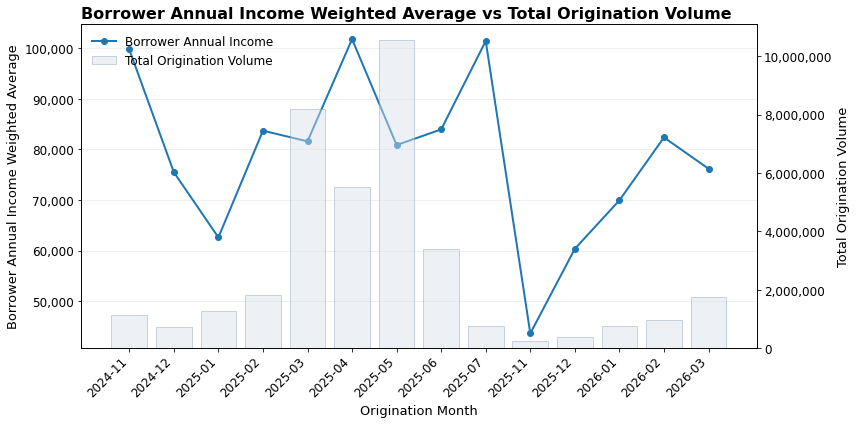

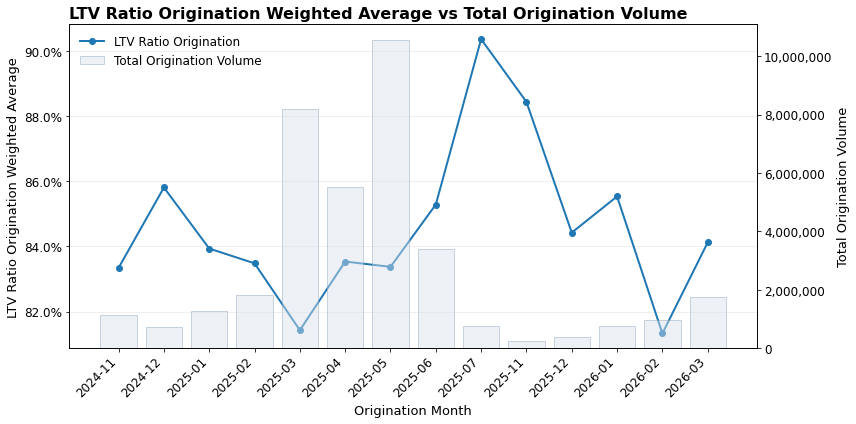

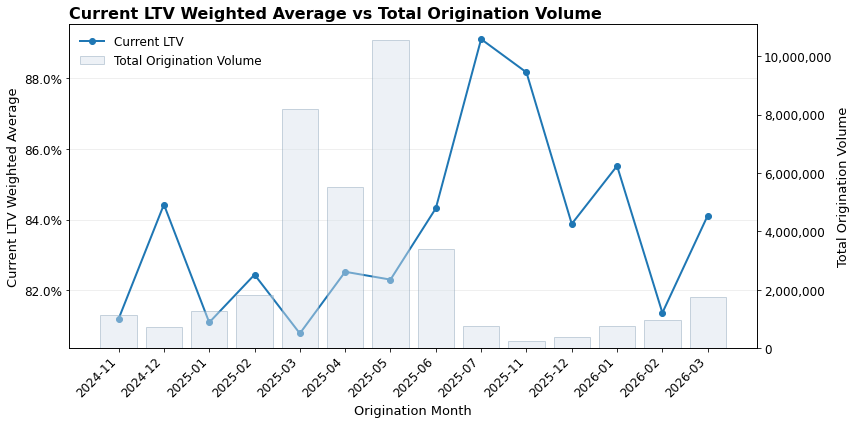

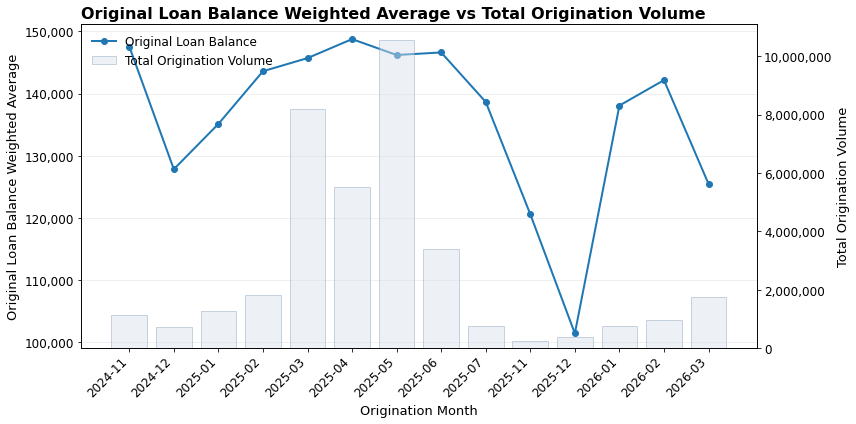

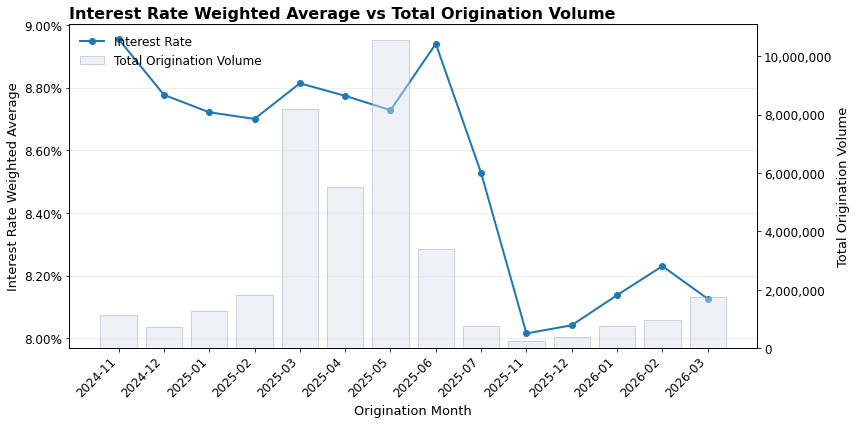

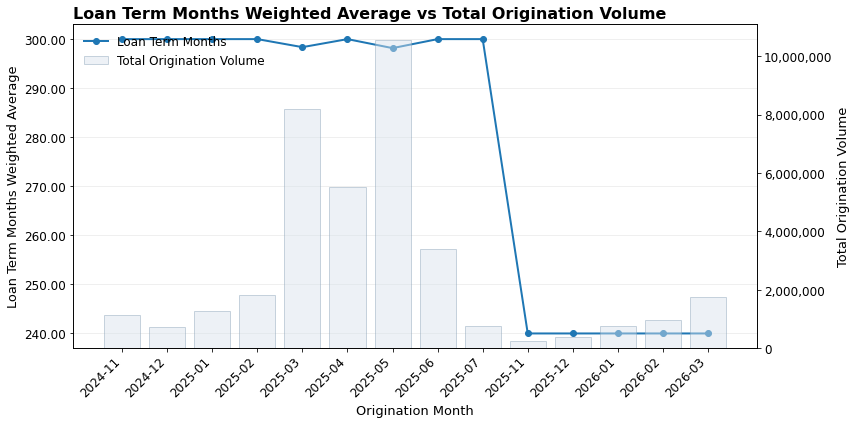

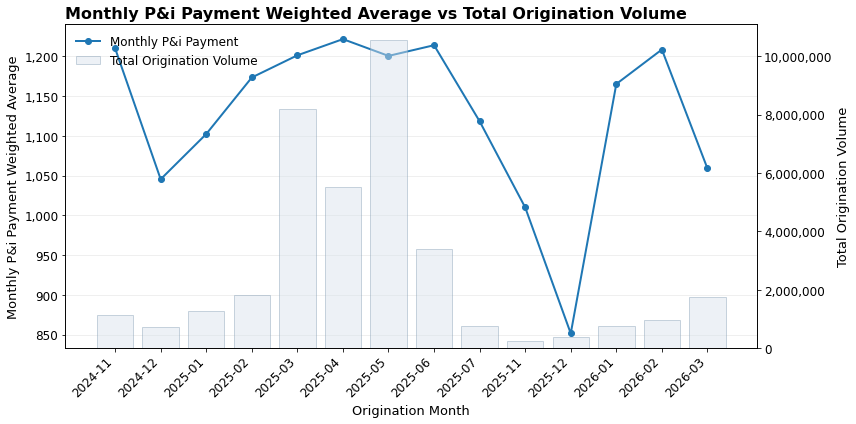

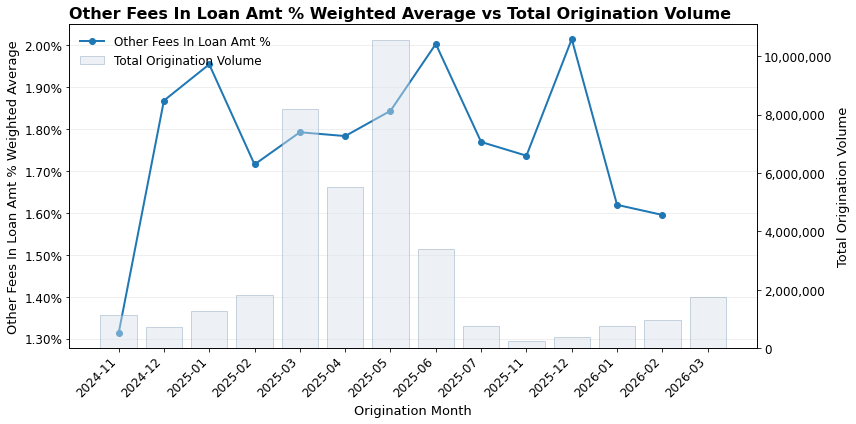

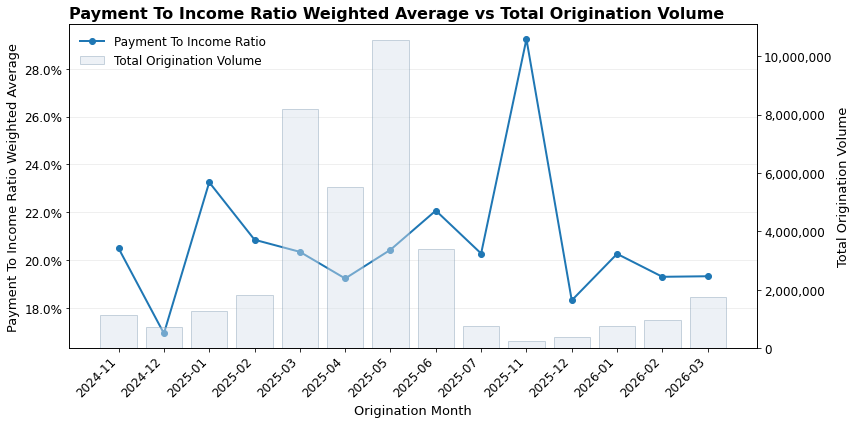

,fico_score,dti_ratio,credit_tier,borrower_annual_income,ltv_ratio_origination,current_ltv,original_loan_balance,interest_rate,loan_term_months,monthly_p&i_payment,other_fees_in_loan_amt %,Payment-to-Income Ratio,Total Origination Volume
Origination Month,,,,,,,,,,,,,
2024-11,688.707873,0.360199,1.635599,99721.275937,0.833426,0.811824,147577.502844,8.954357,300.000000,1210.194887,0.013124,0.204906,1137726.13
2024-12,707.017159,0.432451,1.437274,75495.412451,0.858083,0.844254,127840.617693,8.776761,300.000000,1045.460718,0.018684,0.169273,735119.79
2025-01,752.881353,0.383269,1.223567,62616.788117,0.839353,0.810808,135123.725122,8.721025,300.000000,1102.378482,0.019550,0.232541,1287355.21
2025-02,738.052091,0.402389,1.061567,83685.674173,0.834806,0.824363,143600.046840,8.699933,300.000000,1173.529071,0.017159,0.208491,1834509.44
2025-03,729.683439,0.370368,1.128192,81581.025500,0.814291,0.807692,145710.887970,8.813457,298.362017,1201.428321,0.017928,0.203433,8176233.83
2025-04,740.338584,0.384975,1.104587,101764.051909,0.835358,0.825180,148766.736529,8.773510,300.000000,1221.806505,0.017837,0.192274,5511611.85
2025-05,714.284868,0.379008,1.137290,80851.843336,0.833733,0.822961,146213.191087,8.727781,298.165094,1200.686546,0.018440,0.204303,10560471.9
2025-06,705.012804,0.375717,1.309323,83938.674529,0.852855,0.843165,146621.179995,8.939529,300.000000,1214.128806,0.020037,0.220695,3395298.11
2025-07,755.353272,0.382174,1.000000,101387.993537,0.903620,0.891157,138661.179577,8.527488,300.000000,1118.392922,0.017696,0.202721,750540.37


In [23]:
weighted_avg_by_group = plot_weighted_avg_by_group(
    # origination_raw,
    origination_mod,
    groupby_col=groupby_col,
    cols_to_analyze=cols_to_analyze_numeric,
    weight_col=weighted_col,
    exclude_nonpositive_values = True,
    show=True,
    volume_display = 'right'
)

display(weighted_avg_by_group)

weighted_avg_by_group.rename(columns={col: f"WA {col}" for col in weighted_avg_by_group.columns if col != groupby_col}, inplace=True)

In [25]:
# df_all['charge_off_amount'] = 0

In [25]:
age_cutoff = [6, 9, 12, 18, 24]
dpd_col_name = 'days_delinquent'
default_col_name = 'charge_off_amount'
dpd_num = 60
mob_col_name = 'loan age since first payment'
loan_id_col_name = "new_loan_id"
original_bal_col_name = 'original_loan_balance'
vintage_col_name = 'Origination Month'
mob_orig_data = 0

value_cols = []
for age in age_cutoff:
    everd30_pct_col = "EverD{}% @ MOB{}".format(dpd_num, age)
    value_cols.append(everd30_pct_col)

In [26]:
df_all

,porchpass_id,midwest_loan,madison_acct,old_porchpass_ids,partner_loan_ids,purchase_bundle,borrower_state,period_year,period_month,period_label,...,other_fees_in_loan_amt %,fico_bucket,borrower_annual_income,new_loan_id,porchpass_loan_id,beginning_balance,unpaid_principal_balance,mob,loan age since first payment,charge_off_amount
0,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2024.0,12.0,2024-12,...,0.00492,700-739,411819.00,5001135531,NaN,NaN,NaN,1.0,0.0,0
1,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,1.0,2025-01,...,0.00492,700-739,411819.00,5001135531,NaN,NaN,NaN,2.0,1.0,0
2,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,2.0,2025-02,...,0.00492,700-739,411819.00,5001135531,NaN,NaN,NaN,3.0,2.0,0
3,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,3.0,2025-03,...,0.00492,700-739,411819.00,5001135531,loan_n3EXWUJ9wZiE,111598.50,111506.03,4.0,3.0,0
4,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,4.0,2025-04,...,0.00492,700-739,411819.00,5001135531,loan_n3EXWUJ9wZiE,111506.03,111412.83,5.0,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5587,loan_T3oJ5ukuUqmf,,2011843,20241119.11,2024111911,Bundle 6,TX,2025.0,11.0,2025-11,...,0.029121,780-819,242612.16,,loan_T3oJ5ukuUqmf,92308.13,0.00,8.0,7.0,0
5588,loan_LESKocuKg1z8,,2012158,300003228,300003228,NaN,TX,2025.0,6.0,2025-06,...,0.028797,740-779,58827.12,,loan_LESKocuKg1z8,80337.47,80337.47,2.0,0.0,0
5589,loan_LESKocuKg1z8,,2012158,300003228,300003228,NaN,TX,2025.0,7.0,2025-07,...,0.028797,740-779,58827.12,,loan_LESKocuKg1z8,80337.47,80102.68,3.0,1.0,0
5590,loan_LESKocuKg1z8,,2012158,300003228,300003228,NaN,TX,2025.0,8.0,2025-08,...,0.028797,740-779,58827.12,,loan_LESKocuKg1z8,80102.68,80023.30,4.0,2.0,0


In [27]:
out, ever_dq_co = create_everDQ_MOBn_chart(df_all, 
                             age_cutoff = age_cutoff, 
                             dpd_col_name = dpd_col_name, 
                             default_col_name = default_col_name,
                             dpd_num = dpd_num, 
                             mob_col_name = mob_col_name, 
                             loan_id_col_name = loan_id_col_name,
                             original_bal_col_name = original_bal_col_name,
                             vintage_col_name = vintage_col_name,
                             mob_orig_data = mob_orig_data
                             )

In [28]:
# len(df_all)

In [29]:
# len(origination_raw), len(perf_df_raw)

In [30]:
# display(df_all[(df_all['loan age since first payment'] <= 3) & (df_all['days_past_due'] >= 30 )][['porchpass_loan_id', 
#                                                                                                   'mls_servicer_loan_id',
#                                                                                                   'origination_date', 
#                                                                                                   'period_label', 
#                                                                                                   'loan age since first payment', 
#                                                                                                   'days_past_due', 
#                                                                                                   'months_since_last_delinquency', 
#                                                                                                   'months_to_first_delinquency']])

In [31]:
# df_all

In [32]:
# display(df_all[df_all['new_loan_id'] == 'loan_nozMswH5UjpW'][['new_loan_id', 'origination_date', 'period_label', 
#                                                                     'mob',
#                                                                     'loan age since first payment', 
#                                                                     'first_payment_due',
#                                                                     'days_past_due', 
#                                                                     'expected_monthly_payment',
#                                                                     'actual_payment_pi',
#                                                                     'expected_principal_paid',
#                                                                     'months_since_last_delinquency', 'months_to_first_delinquency']])

In [33]:
# check = df_all.groupby('porchpass_loan_id').agg({
#                                                     'days_past_due': 'max',
#                                                     'months_since_last_delinquency': 'max',
#                                                     'months_to_first_delinquency': 'max'
#                                                 })

In [34]:
# discrepency = check[(check['days_past_due'] >= 30) & (check['months_since_last_delinquency'] == 'Never Delinquent')]
# .to_excel("check.xlsx")

In [35]:
# check[(check['days_past_due'] < 30) & (check['months_since_last_delinquency'] != 'Never Delinquent')].to_excel("check.xlsx")

In [36]:
# display(df_all[df_all['porchpass_loan_id'] == 'new_2024092510'])

In [37]:
# display(df_all[df_all['porchpass_loan_id'] == 'loan_A1gATy1KpFp9'])

In [38]:
# ever_dq_co[(ever_dq_co['everD{} or CO @ MOB{}'.format(dpd_num, age_cutoff[0])] == True) & (ever_dq_co['months_since_last_delinquency'] == 'Never Delinquent')]

In [39]:
# out

In [40]:
# value_cols

In [41]:
everd30_table = out.reset_index().merge(weighted_avg_by_group, on=groupby_col)

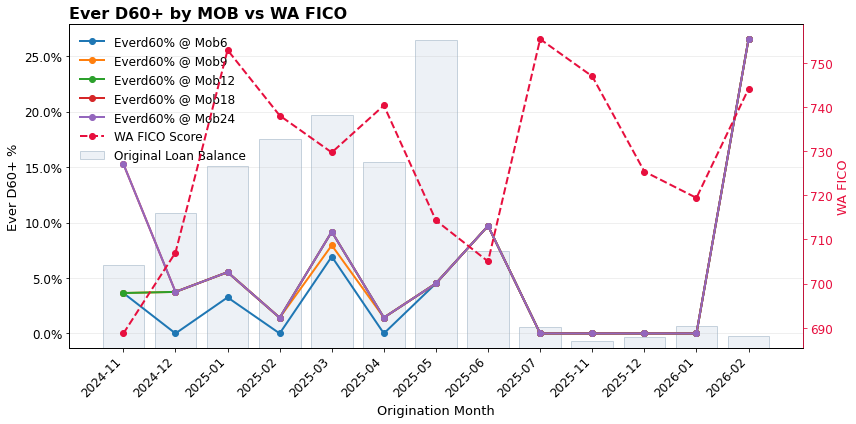

In [42]:
everd30_charts = plot_metric_vs_volume(
    everd30_table.iloc[:, :],
    value_cols=value_cols,
    right_value_cols="WA fico_score",
    volume_col=weighted_col,
    x_col=groupby_col,
    title="Ever D{}+ by MOB vs WA FICO".format(dpd_num),
    x_label=format_column_label(groupby_col),
    value_ylabel="Ever D{}+ %".format(dpd_num),
    right_ylabel="WA FICO",
    volume_ylabel="Original Loan Balance",
    value_y_formatter="percent",
    right_y_formatter="integer",
    right_colors="#e70f3e",
    volume_display="background",  # switch to "right_axis" or "none"
    figsize=(12, 6),
    show=True,
)

In [43]:
# everd30_charts

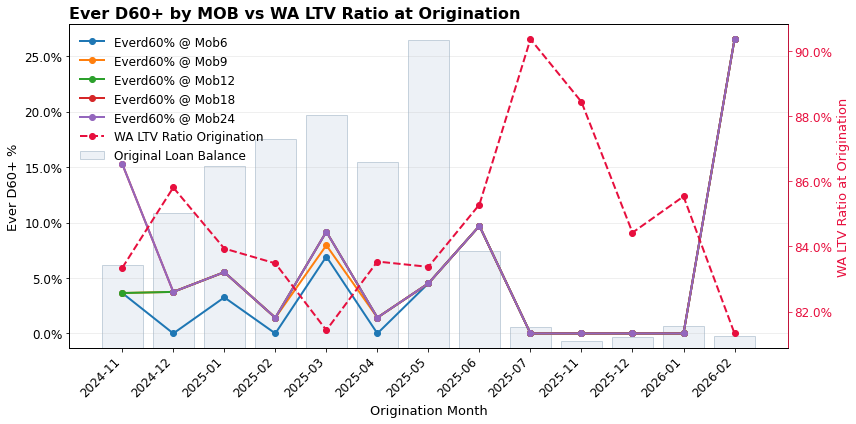

In [44]:
everd30_charts = plot_metric_vs_volume(
    everd30_table.iloc[:, :],
    value_cols=value_cols,
    right_value_cols="WA ltv_ratio_origination",
    volume_col=weighted_col,
    x_col=groupby_col,
    title="Ever D{}+ by MOB vs WA LTV Ratio at Origination".format(dpd_num),
    x_label=format_column_label(groupby_col),
    value_ylabel="Ever D{}+ %".format(dpd_num),
    right_ylabel="WA LTV Ratio at Origination",
    volume_ylabel="Original Loan Balance",
    value_y_formatter="percent",
    right_y_formatter="percent",
    right_colors="#e70f3e",
    volume_display="background",  # switch to "right_axis" or "none"
    figsize=(12, 6),
    show=True,
)

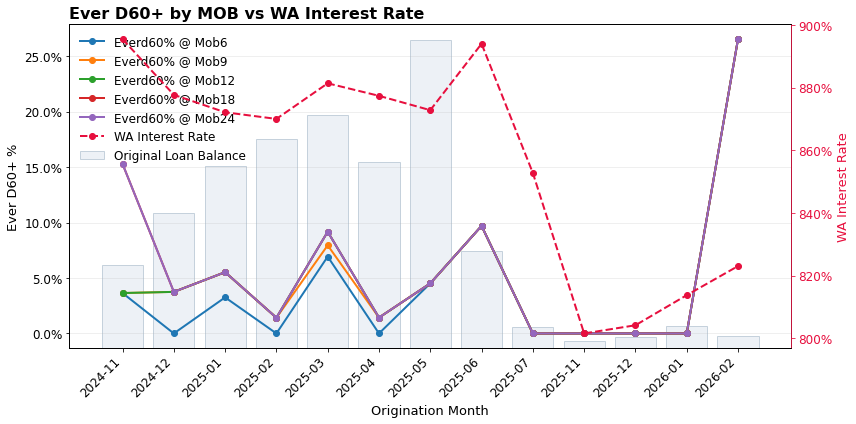

In [45]:
everd30_charts = plot_metric_vs_volume(
    everd30_table,
    value_cols=value_cols,
    right_value_cols="WA interest_rate",
    volume_col=weighted_col,
    x_col=groupby_col,
    title="Ever D{}+ by MOB vs WA Interest Rate".format(dpd_num),
    x_label=format_column_label(groupby_col),
    value_ylabel="Ever D{}+ %".format(dpd_num),
    right_ylabel="WA Interest Rate",
    volume_ylabel="Original Loan Balance",
    value_y_formatter="percent",
    right_y_formatter="percent",
    right_colors="#e70f3e",
    volume_display="background",  # switch to "right_axis" or "none"
    figsize=(12, 6),
    show=True,
)

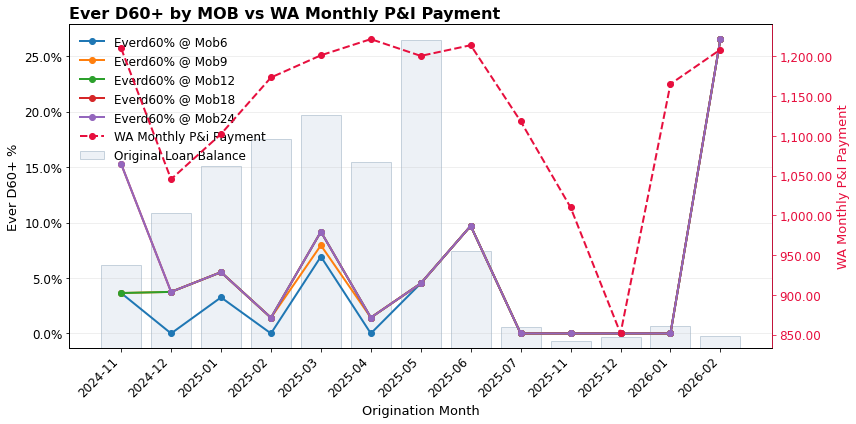

In [46]:
everd30_charts = plot_metric_vs_volume(
    everd30_table,
    value_cols=value_cols,
    right_value_cols="WA monthly_p&i_payment",
    volume_col=weighted_col,
    x_col=groupby_col,
    title="Ever D{}+ by MOB vs WA Monthly P&I Payment".format(dpd_num),
    x_label=format_column_label(groupby_col),
    value_ylabel="Ever D{}+ %".format(dpd_num),
    right_ylabel="WA Monthly P&I Payment",
    volume_ylabel="Original Loan Balance",
    value_y_formatter="percent",
    right_y_formatter="number",
    right_colors="#e70f3e",
    volume_display="background",  # switch to "right_axis" or "none"
    figsize=(12, 6),
    show=True,
)

In [47]:
credit_tier_table = results['credit_tier']['table'].T
credit_tier_table.columns = [f"credit tier {col} %" for col in credit_tier_table.columns]

In [50]:
# credit_tier_table

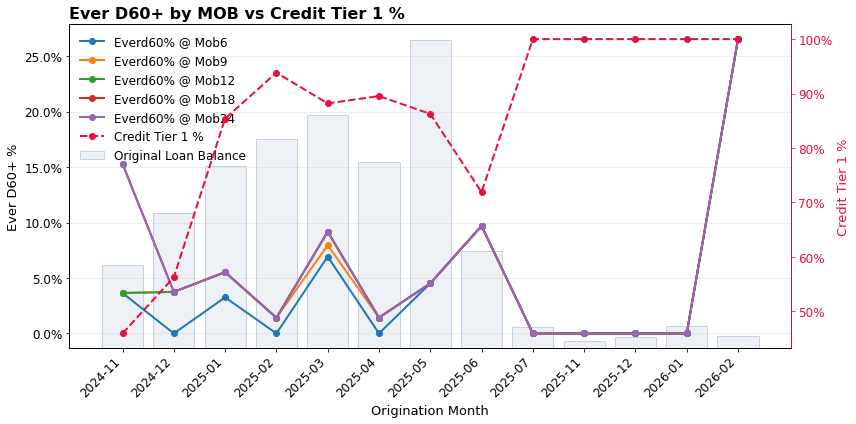

In [51]:
everd30_charts = plot_metric_vs_volume(
    everd30_table.join(credit_tier_table, on=groupby_col),
    value_cols=value_cols,
    right_value_cols="credit tier 1 %",
    volume_col=weighted_col,
    x_col=groupby_col,
    title="Ever D{}+ by MOB vs Credit Tier 1 %".format(dpd_num),
    x_label=format_column_label(groupby_col),
    value_ylabel="Ever D{}+ %".format(dpd_num),
    right_ylabel="Credit Tier 1 %",
    volume_ylabel="Original Loan Balance",
    value_y_formatter="percent",
    right_y_formatter="percent",
    right_colors="#e70f3e",
    volume_display="background",  # switch to "right_axis" or "none"
    figsize=(12, 6),
    show=True,
)

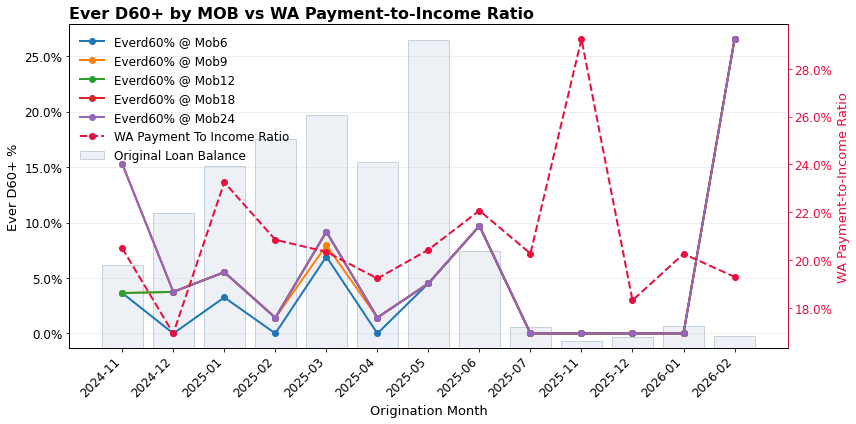

In [52]:
everd30_charts = plot_metric_vs_volume(
    everd30_table.iloc[:, :],
    value_cols=value_cols,
    right_value_cols="WA Payment-to-Income Ratio",
    volume_col=weighted_col,
    x_col=groupby_col,
    title="Ever D{}+ by MOB vs WA Payment-to-Income Ratio".format(dpd_num),
    x_label=format_column_label(groupby_col),
    value_ylabel="Ever D{}+ %".format(dpd_num),
    right_ylabel="WA Payment-to-Income Ratio",
    volume_ylabel="Original Loan Balance",
    value_y_formatter="percent",
    right_y_formatter="percent",
    right_colors="#e70f3e",
    volume_display="background",  # switch to "right_axis" or "none"
    figsize=(12, 6),
    show=True,
)

In [72]:
df_all

,porchpass_id,midwest_loan,madison_acct,old_porchpass_ids,partner_loan_ids,purchase_bundle,borrower_state,period_year,period_month,period_label,...,other_fees_in_loan_amt %,fico_bucket,borrower_annual_income,new_loan_id,porchpass_loan_id,beginning_balance,unpaid_principal_balance,mob,loan age since first payment,charge_off_amount
0,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2024.0,12.0,2024-12,...,0.00492,700-739,411819.00,5001135531,NaN,NaN,NaN,1.0,0.0,0
1,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,1.0,2025-01,...,0.00492,700-739,411819.00,5001135531,NaN,NaN,NaN,2.0,1.0,0
2,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,2.0,2025-02,...,0.00492,700-739,411819.00,5001135531,NaN,NaN,NaN,3.0,2.0,0
3,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,3.0,2025-03,...,0.00492,700-739,411819.00,5001135531,loan_n3EXWUJ9wZiE,111598.50,111506.03,4.0,3.0,0
4,loan_n3EXWUJ9wZiE,5001135531,2011083,20240902.9,202409029,Bundle 3,TX,2025.0,4.0,2025-04,...,0.00492,700-739,411819.00,5001135531,loan_n3EXWUJ9wZiE,111506.03,111412.83,5.0,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5587,loan_T3oJ5ukuUqmf,,2011843,20241119.11,2024111911,Bundle 6,TX,2025.0,11.0,2025-11,...,0.029121,780-819,242612.16,,loan_T3oJ5ukuUqmf,92308.13,0.00,8.0,7.0,0
5588,loan_LESKocuKg1z8,,2012158,300003228,300003228,NaN,TX,2025.0,6.0,2025-06,...,0.028797,740-779,58827.12,,loan_LESKocuKg1z8,80337.47,80337.47,2.0,0.0,0
5589,loan_LESKocuKg1z8,,2012158,300003228,300003228,NaN,TX,2025.0,7.0,2025-07,...,0.028797,740-779,58827.12,,loan_LESKocuKg1z8,80337.47,80102.68,3.0,1.0,0
5590,loan_LESKocuKg1z8,,2012158,300003228,300003228,NaN,TX,2025.0,8.0,2025-08,...,0.028797,740-779,58827.12,,loan_LESKocuKg1z8,80102.68,80023.30,4.0,2.0,0


In [54]:
# perf_df_raw_copy[(perf_df_raw_copy['days_past_due'] >= 30) & ((perf_df_raw_copy['loan_status'] == 'Performing'))]

In [ ]:
perf_df_raw_copy = perf_df.copy()
perf_df_raw_copy['delin_bal'] = ((perf_df_raw_copy['days_delinquent'] >= 30) | (perf_df_raw_copy['loan_status'] == 'Repo')) * perf_df_raw_copy['beginning_balance']
# perf_df_raw_copy['delin_bal'] = (~(perf_df_raw_copy['loan_status'] == 'Performing')) * perf_df_raw_copy['beginning_balance']
dq_df = perf_df_raw_copy.groupby('period_end_date')[['delin_bal', 'beginning_balance']].sum().reset_index().sort_values('period_end_date')
dq_df['delinquency_rate'] = dq_df['delin_bal'] / dq_df['beginning_balance']

In [65]:
perf_df_raw_copy['loan_status'].value_counts()

loan_status
Performing     5336
dq60+           124
Collections      80
Paid Off         52
Name: count, dtype: int64

In [69]:
dq_df

,period_end_date,delin_bal,beginning_balance,delinquency_rate
0,2024-11-30,0.00,0.00,NaN
1,2024-12-31,0.00,427302.61,0.000000
2,2025-01-31,0.00,2469283.00,0.000000
3,2025-02-28,0.00,8734910.57,0.000000
4,2025-03-31,416172.55,15908105.63,0.026161
5,2025-04-30,106267.55,34239741.84,0.003104
6,2025-05-31,727924.21,34857519.22,0.020883
7,2025-06-30,368337.45,48660476.64,0.007570
8,2025-07-31,1145421.68,51227384.78,0.022360
9,2025-08-31,1920196.74,51134741.76,0.037552


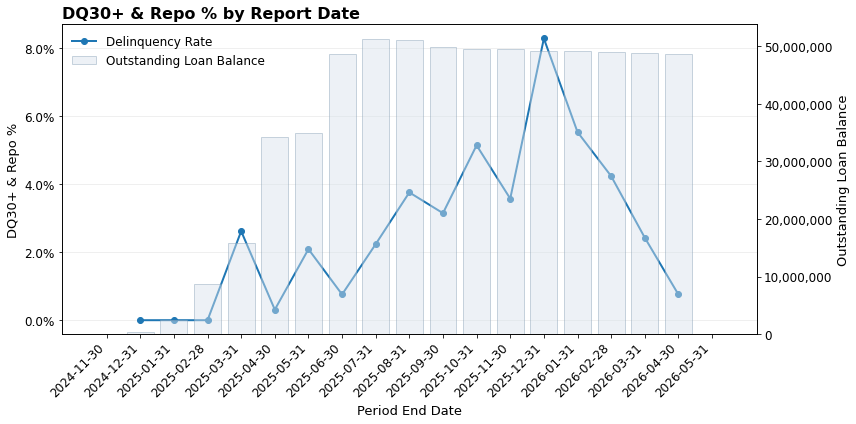

In [67]:
everd30_charts = plot_metric_vs_volume(
    dq_df.iloc[:, :],
    value_cols=['delinquency_rate'],
    right_value_cols=None,
    volume_col='beginning_balance',
    x_col='period_end_date',
    title="DQ30+ & Repo % by Report Date",
    x_label="Period End Date",
    value_ylabel="DQ30+ & Repo %",
    right_ylabel=None,
    volume_ylabel="Outstanding Loan Balance",
    value_y_formatter="percent",
    right_y_formatter="percent",
    right_colors="#e70f3e",
    volume_display="right",  # switch to "right_axis" or "none"
    figsize=(12, 6),
    show=True,
)

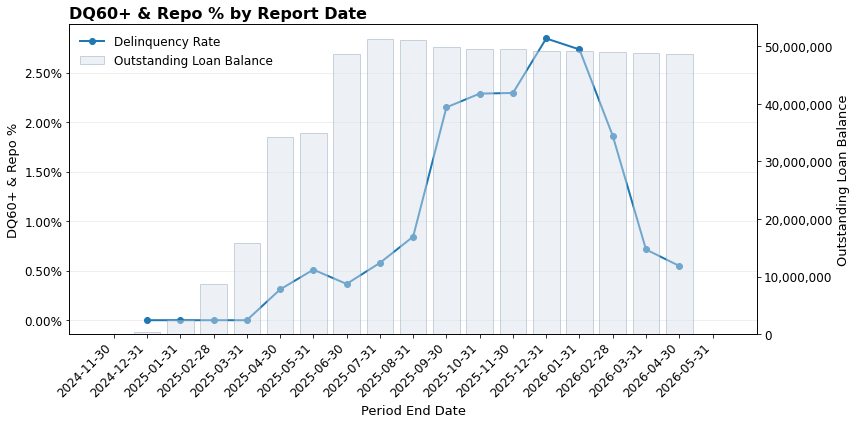

In [71]:
perf_df_raw_copy = perf_df.copy()
perf_df_raw_copy['delin_bal'] = ((perf_df_raw_copy['days_delinquent'] >= 60) | (perf_df_raw_copy['loan_status'] == 'Repo')) * perf_df_raw_copy['beginning_balance']
# perf_df_raw_copy['delin_bal'] = (~(perf_df_raw_copy['loan_status'] == 'Performing')) * perf_df_raw_copy['beginning_balance']
dq_df = perf_df_raw_copy.groupby('period_end_date')[['delin_bal', 'beginning_balance']].sum().reset_index().sort_values('period_end_date')
dq_df['delinquency_rate'] = dq_df['delin_bal'] / dq_df['beginning_balance']

everd60_charts = plot_metric_vs_volume(
    dq_df.iloc[:, :],
    value_cols=['delinquency_rate'],
    right_value_cols=None,
    volume_col='beginning_balance',
    x_col='period_end_date',
    title="DQ60+ & Repo % by Report Date",
    x_label="Period End Date",
    value_ylabel="DQ60+ & Repo %",
    right_ylabel=None,
    volume_ylabel="Outstanding Loan Balance",
    value_y_formatter="percent",
    right_y_formatter="percent",
    right_colors="#e70f3e",
    volume_display="right",  # switch to "right_axis" or "none"
    figsize=(12, 6),
    show=True,
)

In [ ]:
# perf_df_raw[perf_df_raw['porchpass_loan_id'].isin(['loan_Lu8HxFtaCaMS','loan_4hZczKYd3Fz9', 'loan_g8phumwvS8iq'])].to_excel("charged_off_repo_loans.xlsx", index=False)

In [ ]:
# perf_df_raw[perf_df_raw['porchpass_loan_id'].isin(missing_payment_df['porchpass_loan_id'])][[
#                                                                         'porchpass_loan_id', 
#                                                                         # 'mls_servicer_loan_id',
#                                                                         # 'alt_loan_id',
                                                                        
#                                                                        'period_end_date', 
#                                                                        'original_loan_balance',
#                                                                        'beginning_balance',
#                                                                        'expected_monthly_payment',
#                                                                        'actual_payment_pi',
#                                                                        'days_past_due',
#                                                                        'delinquency_flag', 
#                                                                        'loan_status',
#                                                                     #    'report_as_of_date',
#                                                                     #    'times_dq30+_in_past_24_months',
#                                                                     #    'months_since_last_delinquency',
#                                                                     #    'months_to_first_delinquency'
#                                                                        ]].to_excel("discrepency_loans_missing_payment.xlsx", index=False)

In [ ]:
origination_raw

,report_as_of_date,mls_servicer_loan_id,alt_loan_id,fico_score,dti_ratio,credit_tier,borrower_income_frequency,borrower_income,borrower_id_type,borrower_city,...,interest_accrued_30_360,Origination Month,Origination Quarter,land_type_clean,borrower_id_type_clean,borrower_income_frequency_clean,origination fee %,other_fees_in_loan_amt %,fico_bucket,borrower_annual_income
0,2026-03-31,5001135556,2011086,694,0.4400,1,Monthly,3940.87,Driver License,Atascosa,...,363.717939,2024-11,2024Q4,Private Land Not Owned By Customer,Driver License,Monthly,0.045346,0.015918,660-699,47290.44
1,2026-03-31,5001135564,2011087,600,0.4000,3,Bi-Weekly,2670.93,Driver License,Atascosa,...,953.285026,2024-11,2024Q4,Customer Owned Private Land,Driver License,Bi-Weekly,0.045353,0.014183,580-619,69444.18
2,2026-03-31,5001135580,2011091,655,0.3000,2,Monthly,3523.33,Passport,Laredo,...,0.000000,2024-11,2024Q4,Private Land Not Owned By Customer,Passport,Monthly,0.045346,0.017572,620-659,42279.96
3,2026-03-31,5001135531,2011083,713,0.2100,2,Monthly,34318.25,Driver License,New Caney,...,0.000000,2024-11,2024Q4,Customer Owned Private Land,Driver License,Monthly,0.045346,0.004920,700-739,411819.00
4,2026-03-31,5001135572,2011089,654,0.3400,2,Monthly,3809.87,Driver License,Alamo,...,1469.347888,2024-11,2024Q4,Customer Owned Private Land,Driver License,Monthly,0.045346,0.013043,620-659,45718.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,2026-03-31,5001144509,5001144509,725,0.3809,1,Monthly,4821.01,Drivers License,Rising Star,...,0.000000,2026-03,2026Q1,Unknown,Driver License,Monthly,NaN,NaN,700-739,57852.12
430,2026-03-31,5001144491,5001144491,711,0.2818,1,Bi-Weekly,1892.80,Drivers License,Schulenburg,...,0.000000,2026-03,2026Q1,Manufactured Home Community,Driver License,Bi-Weekly,NaN,NaN,700-739,49212.80
431,2026-03-31,5001144483,5001144483,697,0.2379,1,Weekly,2070.40,Drivers License,Edna,...,0.000000,2026-03,2026Q1,Customer Owned Private Land,Driver License,Weekly,NaN,NaN,660-699,107660.80
432,2026-03-31,300005608,300005608,714,0.2975,1,Bi-Weekly,3159.19,Drivers License,Needville,...,0.000000,2026-03,2026Q1,Customer Owned Private Land,Driver License,Bi-Weekly,NaN,NaN,700-739,82138.94


In [ ]:
origination_raw['delinquency_bucket'].value_counts()

Current      411
Paid Off       8
90+ DPD        7
30-59 DPD      6
60-89 DPD      2
Name: delinquency_bucket, dtype: int64

In [ ]:
# origination_raw

In [ ]:
# origination_raw['delinquency_bucket'].value_counts()